In [8]:
import os
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

In [10]:
savefig_path = os.path.join (".")
assert (Path(savefig_path).is_dir())

# Fig.3 NPLS plot for SMRT, RepoRT: unique entrees and all entrees. (HMDB??)

In [71]:
from rdkit.Chem import MolFromSmiles, MolFromInchi

from rdkit import RDConfig

contrib_path = os.path.join(RDConfig.RDContribDir, 'NP_Score')

sys.path.append(contrib_path)

import npscorer

fscore = npscorer.readNPModel()

from scipy.stats import gaussian_kde

import random

reading NP model ...
model in


In [69]:
path2smrt = os.path.join ("..", "data", "SMRT", "SMRT_data.csv")
path2report = os.path.join ("..", "data", "RepoRT", "raw_data", "complete_raw_data.tsv")
path2hmdb = os.path.join (".", "metabolites.csv")


In [70]:
smrt_df = pd.read_csv (path2smrt, sep = ";")
report_df = pd.read_csv (path2report, sep = "\t", dtype = {"dir_id":str})
no_smrt_df = report_df[report_df["dir_id"] != "0186"]
hmdb_df = pd.read_csv(path2hmdb)

C:\Users\leonz\AppData\Local\Temp\ipykernel_25904\1238073584.py:2: DtypeWarning: Columns (2,14,35,37,39,41,43,45,47,49,51,53,55,57,59,61,77,79,81,83,85,87,89,91,93,95,97,99,101,103,117,119,121,123,125,127,129,131,133,135,137,139,141,143,159,161,163,165,167,169,171,173,175,177,179,181,183,185,204,210,216) have mixed types. Specify dtype option on import or set low_memory=False.
  report_df = pd.read_csv (path2report, sep = "\t", dtype = {"dir_id":str})


In [76]:
smrt_inchi_array = smrt_df.loc[:, "inchi"].values
unique_entrees_array = np.unique(no_smrt_df["smiles.std"])
report_all_entrees_smiles = no_smrt_df.loc[:, "smiles.std"].values
hmdb_df.dropna(subset=["SMILES"], inplace=True)
hmdb_smiles_array = hmdb_df.sample(20000).loc[:, "SMILES"].values

In [80]:
smrt_mol_array = [ MolFromInchi (inchi) for inchi in smrt_inchi_array ]
report_all_entrees_mol_array = [ MolFromSmiles (smiles, sanitize=True) for smiles in report_all_entrees_smiles]
report_unique_entrees_mol_array = [ MolFromSmiles(smiles, sanitize=True) for smiles in unique_entrees_array]
hmdb_mol_array = [ MolFromSmiles(smiles, sanitize=True) for smiles in hmdb_smiles_array ]

[18:37:46] Explicit valence for atom # 14 N, 4, is greater than permitted
[18:37:46] ERROR: Explicit valence for atom # 14 N, 4, is greater than permitted

[18:37:46] Explicit valence for atom # 16 N, 4, is greater than permitted
[18:37:46] ERROR: Explicit valence for atom # 16 N, 4, is greater than permitted

[18:37:46] Explicit valence for atom # 16 N, 4, is greater than permitted
[18:37:46] ERROR: Explicit valence for atom # 16 N, 4, is greater than permitted

[18:37:46] Explicit valence for atom # 18 N, 4, is greater than permitted
[18:37:46] ERROR: Explicit valence for atom # 18 N, 4, is greater than permitted

[18:37:47] Explicit valence for atom # 17 N, 4, is greater than permitted
[18:37:47] ERROR: Explicit valence for atom # 17 N, 4, is greater than permitted

[18:37:47] Explicit valence for atom # 15 N, 4, is greater than permitted
[18:37:47] ERROR: Explicit valence for atom # 15 N, 4, is greater than permitted

[18:37:47] Explicit valence for atom # 16 N, 4, is greater than 

In [81]:
smrt_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in smrt_mol_array if mol is not None]
all_entrees_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in report_all_entrees_mol_array if mol is not None]
unique_entrees_npls_array = [ npscorer.scoreMol (mol, fscore) for mol in report_unique_entrees_mol_array if mol is not None]
hmdb_npls_array = [ npscorer.scoreMol(mol, fscore) for mol in hmdb_mol_array if mol is not None]

In [84]:
plt.rcParams["font.family"] = "Times New Roman"

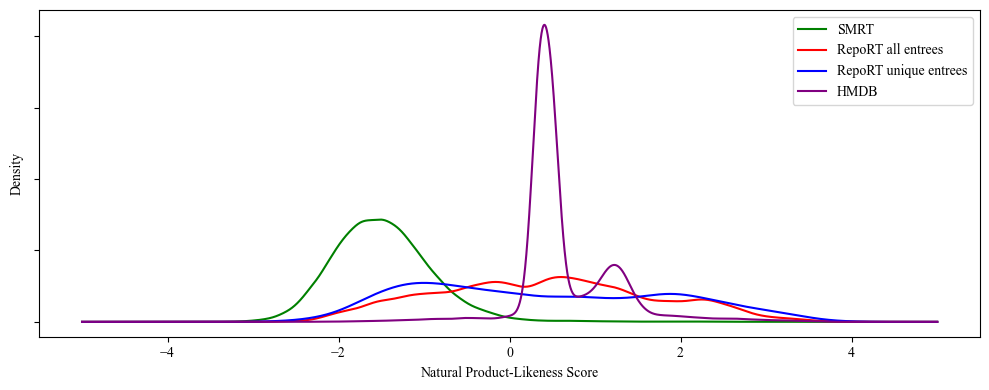

In [85]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
smrt_kde = gaussian_kde(smrt_npls_array, bw_method='silverman')
report_all_kde = gaussian_kde(all_entrees_npls_array, bw_method='silverman')
report_unique_kde = gaussian_kde(unique_entrees_npls_array,bw_method='silverman')
hmdb_kde = gaussian_kde(hmdb_npls_array, bw_method='silverman')
x_val = np.linspace (-5, 5, 5000)
ax.plot (x_val, smrt_kde(x_val), "green", label="SMRT")
ax.plot(x_val, report_all_kde(x_val), "red", label="RepoRT all entrees")
ax.plot (x_val, report_unique_kde(x_val), "blue", label="RepoRT unique entrees")
ax.plot(x_val, hmdb_kde(x_val), "purple", label="HMDB")
ax.set_yticklabels([])
ax.set_xlabel("Natural Product-Likeness Score")
ax.set_ylabel("Density")
plt.legend(loc="upper right")
plt.savefig (os.path.join(savefig_path, "Fig3_NPLS_plot.png"), format="png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()